<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/01_binary_plug_and_play_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Plug-and-Play Simulation

## Goal
In this tutorial, you will learn how to run a forward simulation of the binary crowding model. A "forward simulation" means that we already know the protein parameters and the cosolute (crowder) interaction parameters, and we simply want to calculate how the protein's stability changes as a function of the cosolute concentration.

## Setup
We begin by importing the package and `matplotlib.pyplot` for visualization.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

Cloning into 'ProteinCrowding'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (436/436), done.
remote: Compressing objects: 100% (252/252), done.
remote: Total 436 (delta 222), reused 385 (delta 179), pack-reused 0 (from 0)
Receiving objects: 100% (436/436), 14.10 MiB | 13.49 MiB/s, done.
Resolving deltas: 100% (222/222), done.
Obtaining file:///content/ProteinCrowding
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fh_crowding (pyproject.toml) ... done
  Created wheel for fh_crowding: filename=fh_crowding-0.1.0-0.editable-py3-none-any.whl size=3165 sha256=49dd9b7172256569c75281ca8cf3fa6ccd576bbce3b53f031eca9c23c4546849
  Stored in directory: /tmp/pip-ephem-wheel-cache-_1w3ilrk/wheels/8e/87/c6/59b0297bcdbde056eefb789604b557fd569845c8580cefb7a2
Successfully built fh_crowding


In [2]:
import fh_crowding
import matplotlib.pyplot as plt
import numpy as np

print(f"Module imported successfully: {fh_crowding.__name__}")

Module imported successfully: fh_crowding


## Define the Protein and Cosolute
The Flory-Huggins model requires:
1. **Protein properties:** Primarily its Solvent Accessible Surface Area (SASA) in $A^2$.
2. **Cosolute properties:** The excluded volume parameter ($
u$), and the Flory-Huggins nonideal interaction parameters ($\chi$ and $\chi_{TS}$).

Let's define a hypothetical small protein and a standard cosolute.

In [3]:
# Define the protein (e.g., SASA = 419.0 A^2)
protein = fh_crowding.Protein(SASA=419.0)

# Define the cosolute
cosolute = fh_crowding.Cosolute(
    nu=2.479,      # Excluded volume parameter
    chi=0.610,     # Flory-Huggins interaction parameter
    chiTS=-3.650   # Entropic component of chi
)

## Build and Solve the Model
Now, we construct the `BinaryCrowdingModel`. Since this is a forward simulation, we will arbitrarily set the soft interaction parameters $\varepsilon$ and $\varepsilon_{TS}$ to small non-zero values to see their effect.

We will simulate the concentration range up to $\phi = 0.15$ with a step size of $0.005$.

In [4]:
# Initialize the binary model
model = fh_crowding.BinaryCrowdingModel(
    protein=protein,
    cosolute=cosolute,
    eps=-0.05,        # Soft interaction energy
    epsTS=0.01,       # Entropic component of soft interaction
    phiC_max=0.15,    # Maximum volume fraction to simulate
    dphiC=0.005,      # Step size for the grid
    T=298.15          # Temperature in Kelvin
)

# Solve the thermodynamic equilibrium equations across the concentration grid
model.solve_equil()

## Extract and Plot Results
The `BinaryCrowdingModel` can seamlessly convert all its internal arrays into a `pandas.DataFrame` for easy inspection and plotting.

In [5]:
# Convert results to DataFrame
model.to_pandas()
results = model.results

# Display the first few rows
display(results.head())

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000095,0.9999,0.999905,0.002241,0.002241,0.002241,-0.047195,-2.771956,0.000002,...,1.978132e-09,0.000512,-0.000277,-9.858232e-09,0.000410,0.000410,0.000790,-1.183636e-08,-0.000102,0.000687
1,0.0051,0.004854,0.9949,0.995146,0.114293,0.114879,0.114137,-0.048323,-2.838242,0.000100,...,5.394134e-06,0.026106,-0.014178,-2.688224e-05,0.020885,0.020858,0.040289,-3.227638e-05,-0.005221,0.035036
2,0.0101,0.009601,0.9899,0.990399,0.226346,0.228655,0.225742,-0.049447,-2.904263,0.000204,...,2.215121e-05,0.051639,-0.028170,-1.103929e-04,0.041311,0.041201,0.079831,-1.325441e-04,-0.010328,0.069371
3,0.0151,0.014336,0.9849,0.985664,0.338398,0.343586,0.337069,-0.050567,-2.969993,0.000313,...,5.177826e-05,0.077112,-0.042252,-2.580425e-04,0.061690,0.061432,0.119416,-3.098208e-04,-0.015422,0.103684
4,0.0201,0.019061,0.9799,0.980939,0.450450,0.459690,0.448134,-0.051680,-3.035404,0.000428,...,9.583136e-05,0.102526,-0.056421,-4.775858e-04,0.082020,0.081543,0.159043,-5.734171e-04,-0.020505,0.137964


### Visualizing Thermodynamic Outputs
The package includes built-in plotting utilities that use `matplotlib`. We can instantiate a `BinaryPlotter` to easily visualize $\Delta\Delta G$, $\Delta\Delta H$, and $T\Delta\Delta S$.

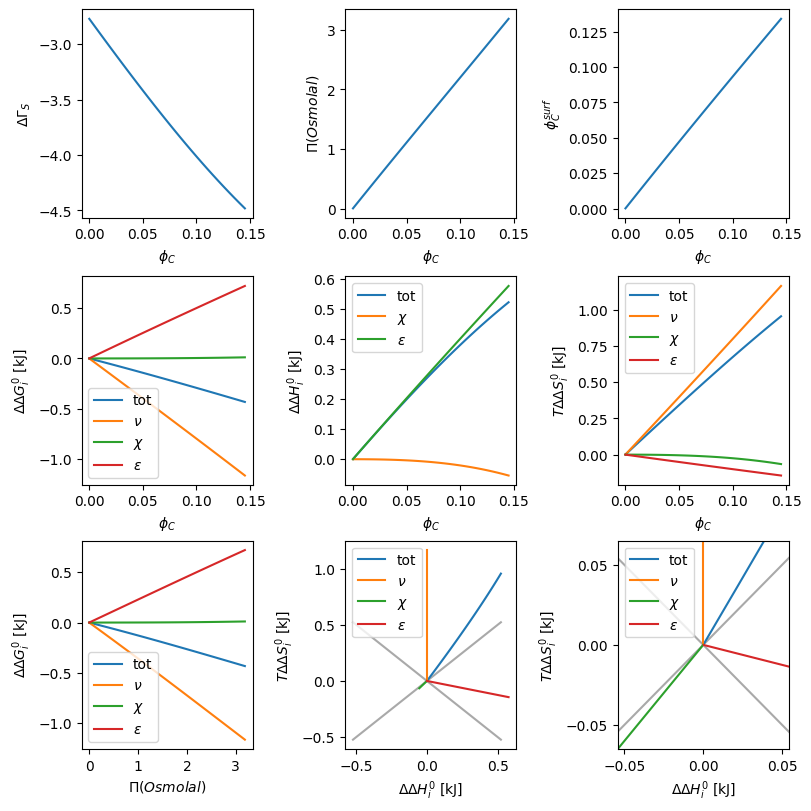

In [6]:
from fh_crowding.plotting import BinaryPlotter

# Create a plotter instance bound to our solved model
plotter = BinaryPlotter(model)

# Plot the stability parameters vs volume fraction
fig = plotter.plot_results()
plt.show()

### Interpretation
- A negative $\Delta\Delta G$ indicates that the cosolute stabilizes the folded state of the protein.
- The `BinaryPlotter` automatically extracted the components of stability ($\Delta\Delta H$ and $T\Delta\Delta S$) from the solved thermodynamic grid.

## Exporting Results
You can export the results DataFrame to a CSV file for your own records or for plotting in other software (e.g., Origin, Prism).

In [7]:
# Export to CSV (commented out to prevent writing during the tutorial)
# results.to_csv("binary_simulation_results.csv", index=False)
print("Simulation complete! You can now analyze the `results` dataframe.")

Simulation complete! You can now analyze the `results` dataframe.
